In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OrdinalEncoder,
    OneHotEncoder,
    PowerTransformer,
    StandardScaler,
)


# classificador referência
from sklearn.dummy import DummyClassifier

# estudo lineares
from sklearn.linear_model import LogisticRegression

# estudo árvores
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# estudo SVM
from sklearn.svm import SVC

# estudo kNN
from sklearn.neighbors import KNeighborsClassifier

# exportar modelo
from joblib import dump

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_TRATADOS, MODELO_FINAL
from src.graficos import plot_comparar_metricas_modelos, plot_coeficientes
from src.models import RANDOM_STATE
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [3]:
colunas_categoricas_nao_ordenadas = [
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
]

colunas_categoricas_ordenadas = [
    #"BusinessTravel"
    "Education",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance",
]

coluna_alvo = ["Attrition"]

colunas_numericas = [
    coluna for coluna in df.columns if coluna not in (
        colunas_categoricas_nao_ordenadas + colunas_categoricas_ordenadas + coluna_alvo + ['BusinessTravel']
    )
]

colunas_numericas

['Age',
 'DailyRate',
 'DistanceFromHome',
 'HourlyRate',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [4]:
colunas_numericas_min_max = [
    'DailyRate',
    'HourlyRate',
    'MonthlyRate'
]

colunas_numericas_std = [
    'Age'
]

colunas_numericas_power = [coluna for coluna in colunas_numericas if coluna not in (colunas_numericas_min_max + colunas_numericas_std)]

colunas_numericas_power

['DistanceFromHome',
 'MonthlyIncome',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [5]:
X = df.drop(columns=coluna_alvo)
y = df[coluna_alvo]

In [6]:
kf = StratifiedKFold(shuffle=True, random_state = RANDOM_STATE)

In [7]:
le = LabelEncoder()

y = le.fit_transform(y)

y[:5]

C:\Users\Lucas\anaconda3\envs\hashtag_ml\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([1, 0, 1, 0, 0])

In [8]:
ordem_business_travel = [['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']]

pre_processamento_arvore = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(drop="first"), colunas_categoricas_nao_ordenadas),
        ("ordinal_encoder", OrdinalEncoder(), colunas_categoricas_ordenadas),

        # Mapeamento ordinal customizado apenas para o BusinessTravel
        ("ordinal_business_travel", OrdinalEncoder(categories=ordem_business_travel), ["BusinessTravel"])
    ]
)

pre_processamento_demais = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(drop="first"), colunas_categoricas_nao_ordenadas),        
        ("ordinal_encoder", OrdinalEncoder(), colunas_categoricas_ordenadas),

        # Mapeamento ordinal customizado apenas para o BusinessTravel
        ("ordinal_business_travel", OrdinalEncoder(categories=ordem_business_travel), ["BusinessTravel"]),
        
        ("min_max", MinMaxScaler(), colunas_numericas_min_max),
        ("std_scaler", StandardScaler(), colunas_numericas_std),
        ("pwr_scaler", PowerTransformer(), colunas_numericas_power)
    ]
)

In [9]:
scale_pos_weight = np.bincount(y)[0] / np.bincount(y)[1]

scale_pos_weight

np.float64(5.2025316455696204)

In [10]:
classificadores = {
    'DummyClassifier': {
        'preprocessor': None,
        'classificador': DummyClassifier(strategy='stratified'),
    },
    'LogisticRegression': {
        'preprocessor': pre_processamento_demais,
        'classificador': LogisticRegression(class_weight='balanced', max_iter=1000),
    },
    'DecisionTreeClassifier': {
        'preprocessor': pre_processamento_arvore,
        'classificador': DecisionTreeClassifier(class_weight='balanced'),
    },
    'LGBMClassifier': {
        'preprocessor': pre_processamento_arvore,
        'classificador': LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            scale_pos_weight=scale_pos_weight
        )
    },
    'XGBClassifier': {
        'preprocessor': pre_processamento_arvore,
        'classificador': XGBClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight
        )
    },
    'SVC': {
        'preprocessor': pre_processamento_demais,
        'classificador': SVC(class_weight='balanced')
    },
    'KNeighborsClassifier': {
        'preprocessor': pre_processamento_demais,
        'classificador': KNeighborsClassifier()
    },
}


In [11]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados


C:\Users\Lucas\anaconda3\envs\hashtag_ml\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lucas\anaconda3\envs\hashtag_ml\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Lucas\anaconda3\envs\hashtag_ml\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lucas\anaconda3\envs\hashtag_ml\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Lucas\anaconda3\envs\hashtag_ml

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.001039,0.008077,0.717687,0.479167,0.126316,0.12766,0.125,0.522358,0.171142,0.009116
1,DummyClassifier,0.0,0.006533,0.683673,0.442073,0.079208,0.075472,0.083333,0.491616,0.161176,0.006533
2,DummyClassifier,0.001027,0.006548,0.717687,0.496038,0.161616,0.153846,0.170213,0.523387,0.167569,0.007576
3,DummyClassifier,0.0,0.006724,0.714286,0.511241,0.192308,0.175439,0.212766,0.500086,0.159887,0.006724
4,DummyClassifier,0.0,0.006546,0.714286,0.494013,0.16,0.150943,0.170213,0.510208,0.162913,0.006546
5,LogisticRegression,0.045373,0.022602,0.731293,0.713669,0.455172,0.340206,0.6875,0.817581,0.566491,0.067975
6,LogisticRegression,0.045938,0.021652,0.761905,0.740346,0.492754,0.377778,0.708333,0.836551,0.619804,0.06759
7,LogisticRegression,0.04182,0.021713,0.758503,0.752907,0.496454,0.37234,0.744681,0.839952,0.655759,0.063533
8,LogisticRegression,0.041954,0.021138,0.789116,0.77974,0.537313,0.413793,0.765957,0.844517,0.657648,0.063092
9,LogisticRegression,0.044782,0.020671,0.77551,0.754415,0.507463,0.390805,0.723404,0.785081,0.577139,0.065453


In [12]:
df_resultados.groupby('model').mean().sort_values('test_f1')

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.000413,0.006886,0.709524,0.484506,0.14389,0.136672,0.152305,0.509531,0.164537,0.007299
KNeighborsClassifier,0.037968,0.073375,0.85034,0.556258,0.206623,0.736797,0.122252,0.678044,0.334898,0.111343
DecisionTreeClassifier,0.013375,0.014318,0.780952,0.608458,0.34024,0.330348,0.353989,0.608458,0.223267,0.027693
XGBClassifier,0.097911,0.022815,0.827211,0.666814,0.445173,0.462168,0.430142,0.777393,0.457685,0.120726
LGBMClassifier,0.125791,0.029639,0.822449,0.684371,0.465104,0.451477,0.480674,0.792395,0.516922,0.15543
LogisticRegression,0.043973,0.021555,0.763265,0.748215,0.497831,0.378984,0.725975,0.824736,0.615368,0.065528
SVC,0.075766,0.079551,0.822449,0.764771,0.554042,0.468235,0.67961,0.832488,0.618109,0.155317


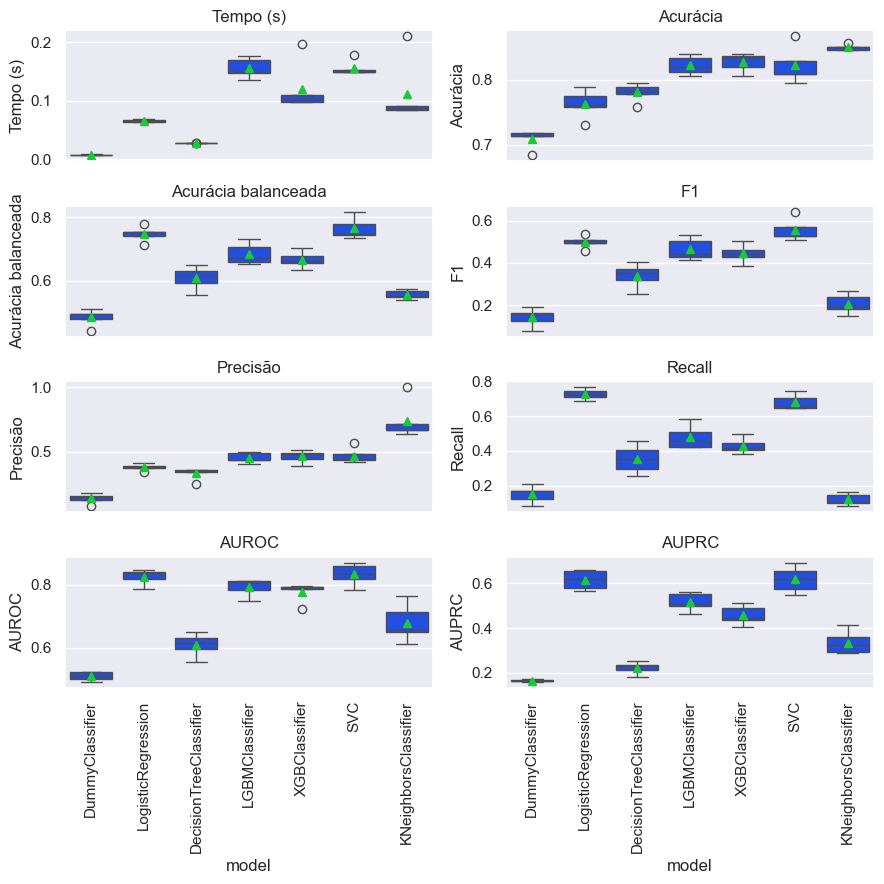

In [13]:
plot_comparar_metricas_modelos(df_resultados)

In [14]:
param_grid = {
    'clf__C' : [0.1, 1, 10, 100],
    'clf__penalty' : ['l1', 'l2', 'elasticnet', None],
    'clf__l1_ratio' : [0.1, 0.25, 0.5, 0.75, 0.9]
}

In [15]:
clf = LogisticRegression(solver='saga', random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, pre_processamento_demais, refit_metric='average_precision' 
)

grid_search

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('one_hot',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Department',
                                                                          'EducationField',
                                                                          'Gender',
                                                                          'JobRole',
                                                                          'MaritalStatus',
                                                                          'OverTime']),
                                                                        ('ordinal_encoder',
                                                                         OrdinalEncoder(),
                                                                         ['Education',
                                                                          'EnvironmentSatisfaction',
                                                                          'JobSatisf...
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['l1', 'l2', 'elasticnet', None]},
             refit='average_precision',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [16]:
grid_search.fit(X,y)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('one_hot',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Department',
                                                                          'EducationField',
                                                                          'Gender',
                                                                          'JobRole',
                                                                          'MaritalStatus',
                                                                          'OverTime']),
                                                                        ('ordinal_encoder',
                                                                         OrdinalEncoder(),
                                                                         ['Education',
                                                                          'EnvironmentSatisfaction',
                                                                          'JobSatisf...
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['l1', 'l2', 'elasticnet', None]},
             refit='average_precision',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [17]:
grid_search.best_params_

{'clf__C': 0.1, 'clf__l1_ratio': 0.5, 'clf__penalty': 'elasticnet'}

In [18]:
grid_search.best_score_

np.float64(0.640357687342653)

In [19]:
grid_search.best_index_

np.int64(10)

In [20]:
grid_search.cv_results_

{'mean_fit_time': array([0.18625975, 0.15709724, 0.13236837, 0.83162904, 0.12798157,
        0.1035583 , 0.11407142, 0.8162858 , 0.1202219 , 0.10752831,
        0.11051831, 0.80997972, 0.12429538, 0.10377674, 0.11810236,
        0.81668482, 0.11811275, 0.10256658, 0.12279859, 0.82259593,
        0.25620675, 0.22021818, 0.27263699, 0.96889024, 0.35002122,
        0.28993125, 0.30189395, 0.94201002, 0.31115599, 0.25980759,
        0.29484301, 0.80677576, 0.24533305, 0.21805573, 0.29746819,
        0.81307979, 0.24349031, 0.21662517, 0.27418561, 0.79845586,
        1.03796492, 0.78405843, 1.05671282, 0.81700778, 1.0345253 ,
        0.75881524, 1.04369993, 0.80432777, 1.02490354, 0.75870986,
        1.04337845, 0.8064528 , 1.03647947, 0.76309381, 1.05046005,
        0.81182303, 1.02676826, 0.75506854, 1.04360228, 0.80691648,
        1.03064952, 0.81179528, 1.0549087 , 0.81664567, 1.03305435,
        0.80838175, 1.04827795, 0.80445204, 1.02817483, 0.80244842,
        1.04948459, 0.81223764,

In [21]:
colunas_test = [coluna for coluna in df_resultados.columns if coluna.startswith('test')]

colunas_test

['test_accuracy',
 'test_balanced_accuracy',
 'test_f1',
 'test_precision',
 'test_recall',
 'test_roc_auc',
 'test_average_precision']

In [22]:
colunas_test_mean = ['mean_' + coluna for coluna in colunas_test]

colunas_test_mean

['mean_test_accuracy',
 'mean_test_balanced_accuracy',
 'mean_test_f1',
 'mean_test_precision',
 'mean_test_recall',
 'mean_test_roc_auc',
 'mean_test_average_precision']

In [23]:
for coluna in colunas_test_mean:
    print(f'{coluna}: {grid_search.cv_results_[coluna][grid_search.best_index_]:.2f}')

mean_test_accuracy: 0.77
mean_test_balanced_accuracy: 0.75
mean_test_f1: 0.50
mean_test_precision: 0.38
mean_test_recall: 0.73
mean_test_roc_auc: 0.83
mean_test_average_precision: 0.64


In [24]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_['clf'].coef_[0],
    grid_search.best_estimator_['preprocessor'].get_feature_names_out()
)

coefs

,coeficiente
ordinal_encoder__JobInvolvement,-0.413797
pwr_scaler__MonthlyIncome,-0.412178
ordinal_encoder__EnvironmentSatisfaction,-0.332025
one_hot__Department_Research & Development,-0.329840
pwr_scaler__TotalWorkingYears,-0.306627
ordinal_encoder__JobSatisfaction,-0.303580
pwr_scaler__YearsInCurrentRole,-0.229537
pwr_scaler__YearsWithCurrManager,-0.222967
ordinal_encoder__WorkLifeBalance,-0.208099
min_max__DailyRate,-0.195775


In [25]:
coefs.query('coeficiente == 0')

,coeficiente
ordinal_encoder__PerformanceRating,0.0
ordinal_encoder__Education,0.0
one_hot__JobRole_Research Director,0.0
one_hot__JobRole_Manager,0.0
one_hot__JobRole_Human Resources,0.0
one_hot__EducationField_Marketing,0.0
one_hot__EducationField_Other,0.0
min_max__HourlyRate,0.0
min_max__MonthlyRate,0.0
one_hot__JobRole_Sales Executive,0.0


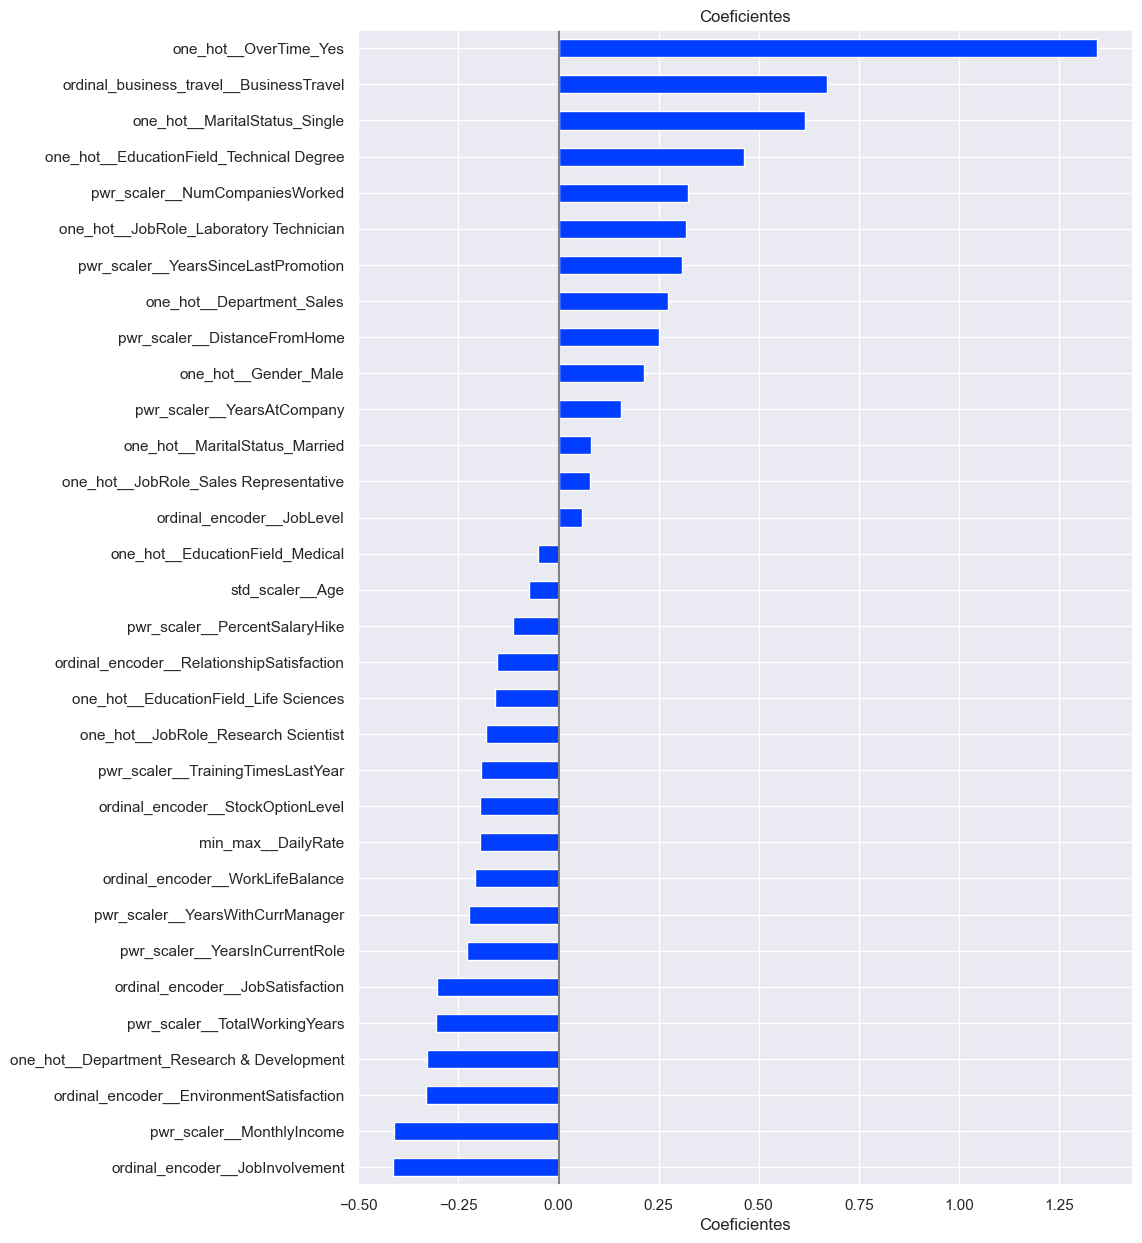

In [26]:
plot_coeficientes(coefs.query('coeficiente != 0'))

In [27]:
coefs_odds = coefs.copy()
coefs_odds['coeficiente'] = np.exp(coefs_odds['coeficiente'])

coefs_odds

,coeficiente
ordinal_encoder__JobInvolvement,0.661135
pwr_scaler__MonthlyIncome,0.662207
ordinal_encoder__EnvironmentSatisfaction,0.717469
one_hot__Department_Research & Development,0.719038
pwr_scaler__TotalWorkingYears,0.735925
ordinal_encoder__JobSatisfaction,0.738171
pwr_scaler__YearsInCurrentRole,0.794902
pwr_scaler__YearsWithCurrManager,0.800141
ordinal_encoder__WorkLifeBalance,0.812127
min_max__DailyRate,0.822197


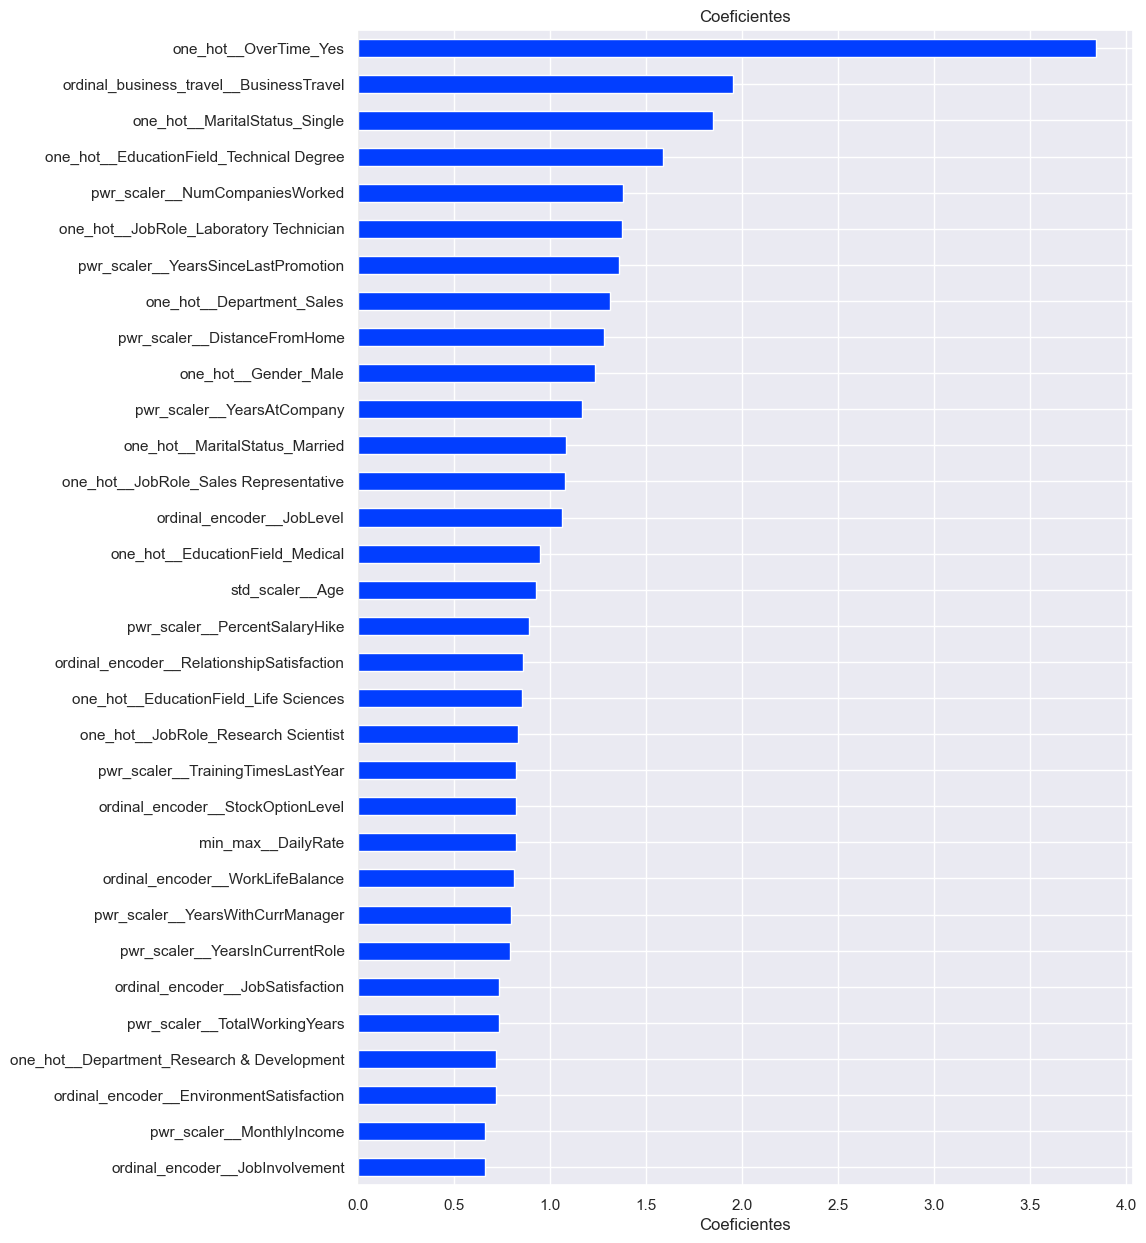

In [28]:
plot_coeficientes(coefs_odds.query('coeficiente != 1'))

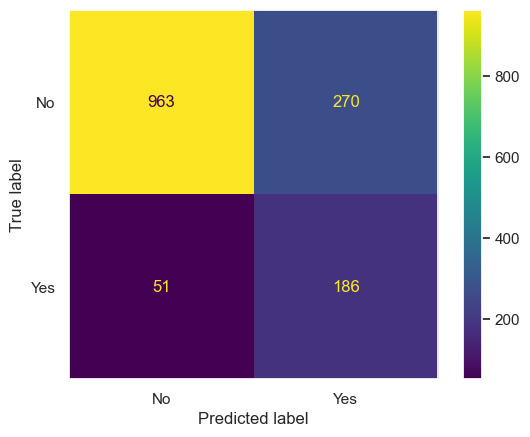

In [29]:
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X,
    y,
    display_labels=le.classes_
)

plt.grid(False)
plt.show()

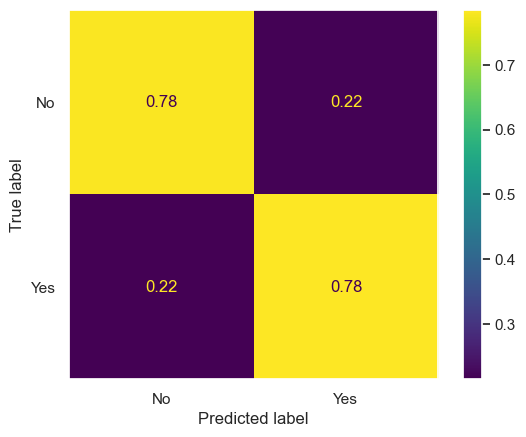

In [30]:
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X,
    y,
    display_labels=le.classes_,
    normalize='true'
)

plt.grid(False)
plt.show()

### Plano de ação:

- Avaliar e eliminar fatores que criam a necessidade de horas extras
    - O trabalho é alocado sem considerar a quantidade de pessoal para realizá-lo
    - Muitas atividades que não agragam valor
    - Equipes inexperientes
- Avaliar e eliminar fatores que criam a necessidade de viagens à trabalho
    - Cultura de reuniões presenciais
    - Realização de prospecção presencial de leads
- Rever como a renda mensal de cada setor se compara com o mercado e realizar ajustes

In [31]:
dump(grid_search.best_estimator_, MODELO_FINAL)

['C:\\Users\\Lucas\\Desktop\\Code\\Hashtag_Ciencia_de_Dados\\IBM-attrition\\modelos\\logistic_regression.joblib']